# 3.1 Introduction to QRenderers

By the end of this tutorial you will understand:

1. How `QRenderer` and `QComponent` share options through the `QGeometry` tables
2. How renderers are registered in `QDesign` and how to access them
3. How to export a full or partial design to GDS and visually inspect the result
4. How to read the `poly`, `path`, and `junction` tables to debug geometry

For convenience, this notebook enables [automatic reloading of modules](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) so any source edits take effect without a kernel restart.

> 💡 **Using this tutorial without the Qt GUI**
> 
> This tutorial uses the desktop `MetalGUI`. To follow along on Colab, Binder, JupyterHub, or any environment where Qt isn't available, **replace any `gui.rebuild()` / `gui.screenshot()` call with `qm.view(design)`** — it renders the design to a matplotlib `Figure` you can display inline or save with `fig.savefig(...)`.
> 
> See [1.4 Headless quick view](../1-Overview/1.4-Headless-quick-view-%28no-Qt-GUI%29.ipynb) for a complete runnable walkthrough and [`docs/headless-usage.rst`](../../docs/headless-usage.rst) for the full reference.

In [1]:
%load_ext autoreload
%autoreload 2

### Import Qiskit Metal

In [2]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings

from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross

from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer

10:56PM 20s WARNING [_maybe_warn_lite_flip]: [FutureWarning] quantum-metal v0.7.0 will move PySide6, qdarkstyle, pyaedt, pyEPR-quantum, and gmsh out of base dependencies into opt-in extras. To preserve the current v0.6.x install behaviour, run `pip install 'quantum-metal[full]'` before upgrading. See ROADMAP.md and docs/migration-to-v0.7.0.rst for details. Set QISKIT_METAL_SUPPRESS_LITE_FLIP_WARNING=1 to silence.


In [3]:
Headings.h1(
    "The default_options in a QComponent are different than the default_options in QRenderers."
)

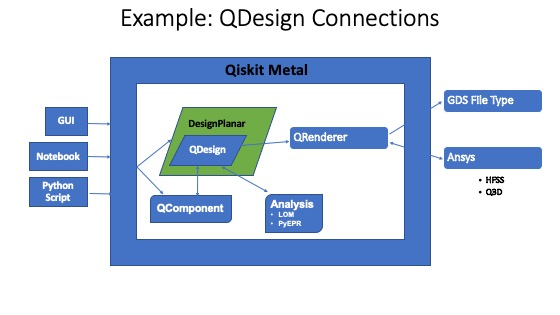

In [4]:
TransmonPocket.default_options

{'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'}}

In [5]:
QGDSRenderer.default_options

{'short_segments_to_not_fillet': 'True',
 'check_short_segments_by_scaling_fillet': '2.0',
 'gds_unit': '1',
 'ground_plane': 'True',
 'negative_mask': {'main': []},
 'fabricate': 'False',
 'corners': 'natural',
 'tolerance': '0.00001',
 'precision': '0.000000001',
 'width_LineString': '10um',
 'path_filename': '../resources/Fake_Junctions.GDS',
 'junction_pad_overlap': '5um',
 'max_points': '199',
 'cheese': {'datatype': '100',
  'shape': '0',
  'cheese_0_x': '25um',
  'cheese_0_y': '25um',
  'cheese_1_radius': '100um',
  'view_in_file': {'main': {1: True}},
  'delta_x': '100um',
  'delta_y': '100um',
  'edge_nocheese': '200um'},
 'no_cheese': {'datatype': '99',
  'buffer': '25um',
  'cap_style': '2',
  'join_style': '2',
  'view_in_file': {'main': {1: True}}},
 'bounding_box_scale_x': '1.2',
 'bounding_box_scale_y': '1.2'}

### A renderer must inherit from `QRenderer`

`QGDSRenderer` inherits from `QRenderer`. When any `QRenderer` is registered
within `QDesign`, the instance gains an `options` dict that starts from
`default_options` and can be updated at runtime or through the GUI.

The two customisation paths are:

1. Update `renderer.options` directly — affects all future exports from that renderer.
2. Pass per-component options when creating a `QComponent` — stored in the `QGeometry`
   table and used by the renderer on export.

### A user can customize things two ways

1.  Directly update the options that originated from default_options, for either QComponent or QRenderer.

2.  Pass options to a QComponent which will be placed in a QGeometry table, then used by QRenderer.

### How to get options from QRenderer to be placed within the QGeometry table?
We set this up so that older QComponents can be agnostic of newer QRenderers. 

The "rate limiting factor" is to have QComponent denote in it's metadata, which QGeometry tables it will write to.  For this example, we will discuss the "junction" table.  More details will be in the notebook at "tutorials/4 Plugin Developer".  
If the QComponent identifies the table which it is aware of, and if QGDSRenderer wants to add a column to the table with a default value, then QComponent will pass the option from QGDSRenderer to QGeometry table without doing anything with it.

An example of this below is `gds_cell_name='FakeJunction_01'`.  This is passed through to QGeometry, when a QComponent is instantiated.  The QGDSRenderer has a default, which is not editable during run-time, but can be customized when a QComponent is instantiated.  

In [6]:
Headings.h1("How does a QRenderer get registered within QDesign?")

### By default, QRenderers are registered within QDesign during init QDesign
The list of QRenderers which will be registered are in qiskit_metal.config.py;   
the dictionary `renderers_to_load` has the name of the QRenderer (key), class name (value), and path (value).

Presently, GDS and Ansys QRenderers are registered during init.  


In [7]:
design = designs.DesignPlanar()

In [8]:
# Use GDS QRenderer for remaining examples.  Can do similar things with Ansys QRenderer.

# an_ansys = design._renderers['ansys']
# an_ansys = design._renderers.ansys

# a_gds = design._renderers['gds']
a_gds = design._renderers.gds

In [9]:
gui = MetalGUI(design)
design.overwrite_enabled = True

In [10]:
Headings.h1("Populate QDesign to demonstrate exporting to GDS format.")

In [11]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# Allow running the same cell here multiple times to overwrite changes
design.overwrite_enabled = True

## Custom options for all the transmons
options = dict(
    # Some options we want to modify from the deafults
    # (see below for defaults)
    pad_width="425 um",
    pad_gap="80 um",
    pocket_height="650um",
    # Adding 4 connectors (see below for defaults)
    connection_pads=dict(
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

> **`gds_cell_name`** — each qubit carries a `gds_cell_name` option that tells the
> GDS renderer which cell to pull from `gds.options.path_filename` and place at
> the junction slot. The four qubits here use three different cells
> (`FakeJunction_01`, `FakeJunction_02`, `my_other_junction`) so you can see all
> three in one export and check that orientation is handled correctly.

In [12]:
## Create 4 TransmonPockets

q1 = TransmonPocket(
    design,
    "Q1",
    options=dict(
        pos_x="+2.55mm", pos_y="+0.0mm", gds_cell_name="FakeJunction_02", **options
    ),
)
q2 = TransmonPocket(
    design,
    "Q2",
    options=dict(
        pos_x="+0.0mm",
        pos_y="-0.9mm",
        orientation="90",
        gds_cell_name="FakeJunction_02",
        **options,
    ),
)
q3 = TransmonPocket(
    design,
    "Q3",
    options=dict(
        pos_x="-2.55mm", pos_y="+0.0mm", gds_cell_name="FakeJunction_01", **options
    ),
)
q4 = TransmonPocket(
    design,
    "Q4",
    options=dict(
        pos_x="+0.0mm",
        pos_y="+0.9mm",
        orientation="90",
        gds_cell_name="my_other_junction",
        **options,
    ),
)

In [13]:
## Rebuild the design
gui.rebuild()
gui.autoscale()

# Connect using techniques explained earlier notebooks.

from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

RouteMeander.get_template_options(design)

options = Dict(meander=Dict(lead_start="0.1mm", lead_end="0.1mm", asymmetry="0 um"))


def connect(
    component_name: str,
    component1: str,
    pin1: str,
    component2: str,
    pin2: str,
    length: str,
    asymmetry="0 um",
    flip=False,
    fillet="50um",
):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        fillet=fillet,
        pin_inputs=Dict(
            start_pin=Dict(component=component1, pin=pin1),
            end_pin=Dict(component=component2, pin=pin2),
        ),
        lead=Dict(start_straight="0.13mm", end_straight="0.13mm"),
        total_length=length,
    )
    myoptions.update(options)
    myoptions.meander.asymmetry = asymmetry
    myoptions.meander.lead_direction_inverted = "true" if flip else "false"
    return RouteMeander(design, component_name, myoptions)


asym = 90
cpw1 = connect("cpw1", "Q1", "d", "Q2", "c", "5.7 mm", f"+{asym}um", fillet="25um")
cpw2 = connect(
    "cpw2", "Q3", "c", "Q2", "a", "5.4 mm", f"-{asym}um", flip=True, fillet="100um"
)
cpw3 = connect("cpw3", "Q3", "a", "Q4", "b", "5.3 mm", f"+{asym}um", fillet="75um")
cpw4 = connect("cpw4", "Q1", "b", "Q4", "d", "5.5 mm", f"-{asym}um", flip=True)

gui.rebuild()
gui.autoscale()

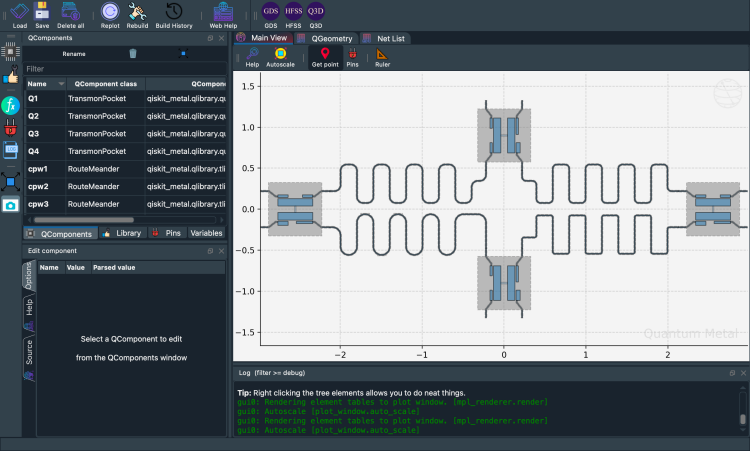

In [14]:
gui.screenshot()
# Headless alternative: qm.view(design)

In [15]:
Headings.h1("Exporting a GDS file.")

In [16]:
# QDesign enables GDS renderer during init.
a_gds = design.renderers.gds
# An alternate way to envoke the gds commands without using a_gds:
# design.renderers.gds.export_to_gds()

# Show the options for GDS
a_gds.options

{'short_segments_to_not_fillet': 'True',
 'check_short_segments_by_scaling_fillet': '2.0',
 'gds_unit': 0.001,
 'ground_plane': 'True',
 'negative_mask': {'main': []},
 'fabricate': 'False',
 'corners': 'natural',
 'tolerance': '0.00001',
 'precision': '0.000000001',
 'width_LineString': '10um',
 'path_filename': '../resources/Fake_Junctions.GDS',
 'junction_pad_overlap': '5um',
 'max_points': '199',
 'cheese': {'datatype': '100',
  'shape': '0',
  'cheese_0_x': '25um',
  'cheese_0_y': '25um',
  'cheese_1_radius': '100um',
  'view_in_file': {'main': {1: True}},
  'delta_x': '100um',
  'delta_y': '100um',
  'edge_nocheese': '200um'},
 'no_cheese': {'datatype': '99',
  'buffer': '25um',
  'cap_style': '2',
  'join_style': '2',
  'view_in_file': {'main': {1: True}}},
 'bounding_box_scale_x': '1.2',
 'bounding_box_scale_y': '1.2'}

###  To make the junction table work correctly, GDS Renderer needs the correct path to the gds file which has cells
Each cell is a junction to be placed in a Transmon.  A sample gds file is provided in directory `qiskit_metal/tutorials/resources`.
There are three cells with names "Fake_Junction_01", "Fake_Junction_01", and "my_other_junction".
The default name used by GDS Render is "my_other_junction".  If you want to customize and select a junction, through the options, 
you can pass it when a qcomponent is being added to QDesign. 

This allows for an already prepared e-beam pattern for a given junction structure to be automatically imported and placed at the correct
location.

In [17]:
a_gds.options["path_filename"] = "../resources/Fake_Junctions.GDS"

### Short-segment fillet handling

When a CPW segment is shorter than `2 × fillet_value`, applying the fillet would
produce overlapping arcs. Set `short_segments_to_not_fillet = True` to skip
filleting on those segments rather than producing invalid geometry.
`check_short_segments_by_scaling_fillet` controls the threshold multiplier
(default `2.0` — i.e. segments shorter than `2 × fillet` are skipped).

In [18]:
# If you have a fillet_value and there are LineSegments that are shorter than 2*fillet_value,
# When true, the short segments will not be fillet'd.
a_gds.options["short_segments_to_not_fillet"] = "True"
scale_fillet = 2.0
a_gds.options["check_short_segments_by_scaling_fillet"] = scale_fillet

In [19]:
# Export GDS file for all components in design.
# def export_to_gds(self, file_name: str, highlight_qcomponents: list = []) -> int:


# Please change the path where you want to write a GDS file.
# Examples below.
# a_gds.export_to_gds("../../../gds-files/GDS QRenderer Notebook.gds")

a_gds.export_to_gds("GDS QRenderer Notebook.gds")

10:56PM 31s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

In [20]:
# Export a GDS file which contains only few components.

# You will probably want to put the exported file in a specific directory.
# Please give the full path for output.
a_gds.export_to_gds(
    "four_qcomponents.gds", highlight_qcomponents=["cpw1", "cpw4", "Q1", "Q3"]
)

10:56PM 32s INFO [import_junction_gds_file]: Rescaling imported junction library from unit=1e-06 to unit=0.001 (scale factor=0.001).


1

## Viewing the exported GDS

`debug_summarize_gds_library` gives a chip-level overview rendered as an embedded SVG.
After that, `plot_gds_zoom` clips a small window around each qubit so you can inspect
junction placement and pad geometry at fabrication scale — no KLayout required.

> **Note:** if `MetalGUI` above switched matplotlib to the Qt6Agg backend,
> run `%matplotlib inline` before the plotting cells (already done below).

In [21]:
import gdstk

lib = gdstk.read_gds("GDS QRenderer Notebook.gds")

# show=True embeds an SVG of the full chip directly in this cell output.
# Increase scale for a larger chip or more detail (default 100).
a_gds.debug_summarize_gds_library(lib, show=True, scale=80, width=900)


=== GDS LIBRARY SUMMARY ===
name:      library
unit:      0.001
precision: 1e-09
cells:     15

CELLS:
  - TOP                            geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - TOP_main                       geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - TOP_main_1                     geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - ground_main_1                  geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - my_other_junction              geom=True bbox=((-0.015, -0.0015), (0.015, 0.0015))
  - FakeJunction_02                geom=True bbox=((-0.015, -0.0015), (0.015, 0.0015))
  - FakeJunction_01                geom=True bbox=((-0.015, -0.001503), (0.015, 0.0015))
  - pads_FakeJunction_02_QComponent_is_1_name_is_rect_jj geom=True bbox=((-0.04, -0.01), (0.04, 0.01))
  - pads_FakeJunction_02_QComponent_is_2_name_is_rect_jj geom=True bbox=((-0.04, -0.01), (0.04, 0.01))
  - pads_FakeJunction_01_QComponent_is_3_name_is_rect_jj geom=True bbox=((-0.04, -0.010001999999999999), (0.04, 0.00999

### GDS layer legend

The renderer writes geometry across several **layer / datatype** pairs.
The layer number matches the `layer` option on each component (default `1`).
The datatype encodes *how* the geometry was produced:

| Layer | DType | Content |
|-------|-------|---------|
| 1 | 0 | **Final metal pattern** — ground plane, qubit pockets, and all pad polygons after boolean merge |
| 1 | 10 | **Component polygon inputs** — individual pad / pocket outlines *before* the boolean merge (useful for debugging geometry) |
| 1 | 11 | **CPW traces** — `FlexPath` geometry for routes, transmission lines, and connectors |
| 1 | 99 | **No-cheese keepout** — buffer region around component pads where cheesing is suppressed; set by `gds.options.no_cheese.datatype` (default `99`) |
| 1 | 100 | **Cheese hole grid (full)** — the complete rectangular array of holes *before* the keepout is subtracted; debug intermediate, set by `gds.options.cheese.datatype` (default `100`) |
| 1 | 101 | **Cheese holes (final)** — grid minus keepout region; these are the holes that will be etched out of the ground plane (`cheese.datatype + 1`) |
| 1 | 102 | **Template hole** — single unit hole at the origin used to stamp the grid via cell references; removed when `fabricate=True` (`cheese.datatype + 2`) |
| 53 | 0 | **Junction primary layer** — polygons imported from the junction GDS file (`FakeJunction_01/02`) |
| 54 | 0 | **Junction secondary layer** — second contact layer from the same junction GDS file |

> **Layer numbers 53 and 54** come from whatever layers your junction cell GDS uses —
> if you supply your own junction file, its layer numbers will appear here instead.
>
> **Datatypes 99–102** only appear when cheesing is enabled
> (`gds.options.cheese.view_in_file` lists the layers to cheese).
> Set `fabricate=True` to strip the debug intermediates (100 and 102) from the final file,
> leaving only the keepout (99) and the final hole set (101).

### Zooming into each qubit

A 200 µm window centred on each transmon pocket lets you verify that the junction cell
was placed correctly and oriented to match the qubit's `orientation` option.

| Qubit | Position | orientation | Junction cell |
|-------|----------|-------------|---------------|
| Q1 | (2.55, 0) mm | 0° | FakeJunction_02 |
| Q2 | (0, −0.9) mm | 90° | FakeJunction_02 |
| Q3 | (−2.55, 0) mm | 0° | FakeJunction_01 |
| Q4 | (0, +0.9) mm | 90° | my_other_junction |

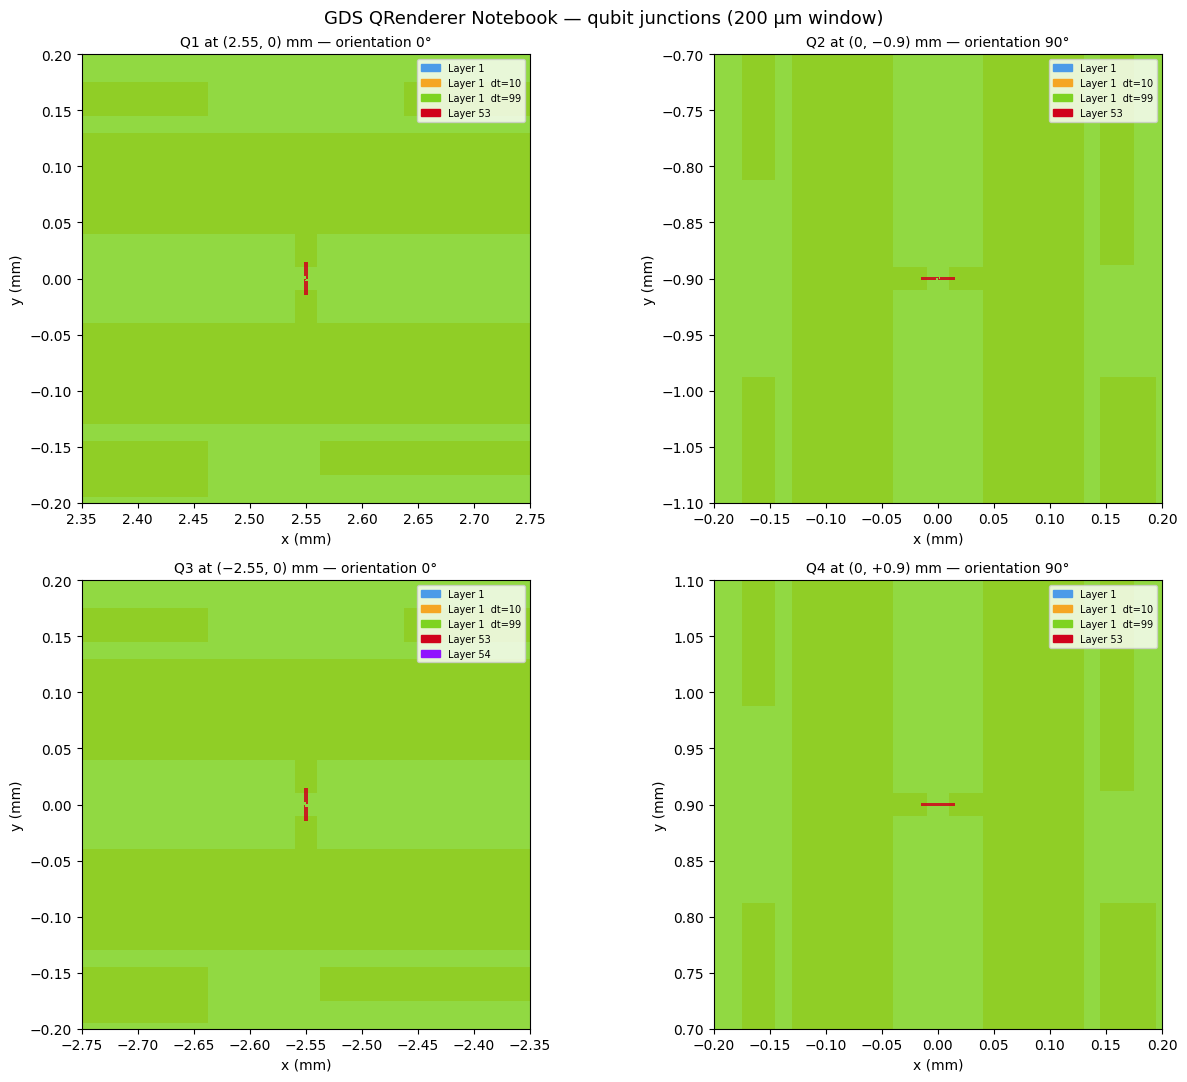

In [22]:
# Reset to the inline backend in case MetalGUI switched it to Qt6Agg.
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle("GDS QRenderer Notebook — qubit junctions (200 µm window)", fontsize=13)

a_gds.plot_gds_zoom(
    lib,
    center_mm=(2.55, 0.0),
    span_mm=0.2,
    title="Q1 at (2.55, 0) mm — orientation 0°",
    ax=axes[0, 0],
)
a_gds.plot_gds_zoom(
    lib,
    center_mm=(0.0, -0.9),
    span_mm=0.2,
    title="Q2 at (0, −0.9) mm — orientation 90°",
    ax=axes[0, 1],
)
a_gds.plot_gds_zoom(
    lib,
    center_mm=(-2.55, 0.0),
    span_mm=0.2,
    title="Q3 at (−2.55, 0) mm — orientation 0°",
    ax=axes[1, 0],
)
a_gds.plot_gds_zoom(
    lib,
    center_mm=(0.0, +0.9),
    span_mm=0.2,
    title="Q4 at (0, +0.9) mm — orientation 90°",
    ax=axes[1, 1],
)

plt.tight_layout()
# plt.close(fig)

## Exporting from the GUI

Within the GUI, the GDS, HFSS, and Q3D toolbar icons trigger the same export
pipeline as `export_to_gds()`. Select the components you want, set the output
path, and click the icon — the renderer reads from the same `QGeometry` tables
that the notebook cells use.

---

The next section looks under the hood at those `QGeometry` tables — understanding
them is useful for debugging unexpected geometry in the exported GDS.

In [23]:
Headings.h1("QUESTION:  Where is the geometry of a QComponent placed?")

### Answer:  QGeometry tables!

## What is QGeometry? 

###  All QRenderers use the QGeometry tables to export from QDesign.  Each table is a Pandas DataFrame.


We can get all the QGeometry of a QComponent. There are several kinds, such as `path`, `poly` and, `junction`. 

In [24]:
# Uncomment any line to display that table in full:
# design.qgeometry.tables          # dict of all tables
# design.qgeometry.tables['path']   # all CPW paths
# design.qgeometry.tables['poly']   # all polygons

In [25]:
design.qgeometry.tables["junction"]

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (2.55 -0.04, 2.55 0.04)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_02,1.000000e-08,0,1.000000e-08,0
1,2,rect_jj,"LINESTRING (0.04 -0.9, -0.04 -0.9)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_02,1.000000e-08,0,1.000000e-08,0
2,3,rect_jj,"LINESTRING (-2.55 -0.04, -2.55 0.04)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
3,4,rect_jj,"LINESTRING (0.04 0.9, -0.04 0.9)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


### Let us look at all the polygons used to create qubit `q1`

Poly table hold the polygons identified from QComponents.

In [26]:
q1.qgeometry_table("poly")

,component,name,geometry,layer,subtract,helper,chip,fillet
0,1,pad_top,"POLYGON ((2.3375 0.04, 2.7625 0.04, 2.7625 0.1...",1,False,False,main,NaN
1,1,pad_bot,"POLYGON ((2.3375 -0.13, 2.7625 -0.13, 2.7625 -...",1,False,False,main,NaN
2,1,rect_pk,"POLYGON ((2.225 -0.325, 2.875 -0.325, 2.875 0....",1,True,False,main,NaN
3,1,a_connector_pad,"POLYGON ((2.6375 0.145, 2.7625 0.145, 2.7625 0...",1,False,False,main,NaN
4,1,b_connector_pad,"POLYGON ((2.4625 0.145, 2.3375 0.145, 2.3375 0...",1,False,False,main,NaN
5,1,c_connector_pad,"POLYGON ((2.5625 -0.145, 2.7625 -0.145, 2.7625...",1,False,False,main,NaN
6,1,d_connector_pad,"POLYGON ((2.4625 -0.145, 2.3375 -0.145, 2.3375...",1,False,False,main,NaN


Paths are lines. These can have a width.

In [27]:
q1.qgeometry_table("path")

,component,name,geometry,layer,subtract,helper,chip,width,fillet,hfss_wire_bonds,q3d_wire_bonds,aedt_q3d_wire_bonds,aedt_hfss_wire_bonds
0,1,a_wire,"LINESTRING (2.7625 0.155, 2.7875 0.155, 2.87 0...",1,False,False,main,0.010,NaN,False,False,False,False
1,1,a_wire_sub,"LINESTRING (2.7625 0.155, 2.7875 0.155, 2.87 0...",1,True,False,main,0.022,NaN,False,False,False,False
2,1,b_wire,"LINESTRING (2.3375 0.155, 2.3125 0.155, 2.23 0...",1,False,False,main,0.010,NaN,False,False,False,False
3,1,b_wire_sub,"LINESTRING (2.3375 0.155, 2.3125 0.155, 2.23 0...",1,True,False,main,0.022,NaN,False,False,False,False
4,1,c_wire,"LINESTRING (2.7625 -0.155, 2.7875 -0.155, 2.87...",1,False,False,main,0.010,NaN,False,False,False,False
5,1,c_wire_sub,"LINESTRING (2.7625 -0.155, 2.7875 -0.155, 2.87...",1,True,False,main,0.022,NaN,False,False,False,False
6,1,d_wire,"LINESTRING (2.3375 -0.155, 2.3125 -0.155, 2.23...",1,False,False,main,0.010,NaN,False,False,False,False
7,1,d_wire_sub,"LINESTRING (2.3375 -0.155, 2.3125 -0.155, 2.23...",1,True,False,main,0.022,NaN,False,False,False,False


### The junction table is handled differently by each renderer

The GDS renderer reads `gds_cell_name` from each junction row, imports that cell
from `gds.options.path_filename`, and places it at the location and orientation
encoded in the junction geometry. The full walkthrough is in
[3.2 — Export your design to GDS](3.2-Export-your-design-to-GDS.ipynb).

In [28]:
q1.qgeometry_table("junction")

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (2.55 -0.04, 2.55 0.04)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_02,1.000000e-08,0,1.000000e-08,0


### Geometric boundary of a `QComponent`

`qcomponent.qgeometry_bounds()` returns `(minx, miny, maxx, maxy)` covering all
geometry that component contributed to the design.

In [29]:
for name, qcomponent in design.components.items():
    print(f"{name:10s} : {qcomponent.qgeometry_bounds()}")

Q1         : [ 2.125 -0.325  2.975  0.325]
Q2         : [-0.325 -1.325  0.325 -0.475]
Q3         : [-2.975 -0.325 -2.125  0.325]
Q4         : [-0.325  0.475  0.325  1.325]
cpw1       : [ 0.22       -0.54399198  2.125      -0.07600802]
cpw2       : [-2.125      -0.55810289 -0.22       -0.06189711]
cpw3       : [-2.125       0.07552405 -0.22        0.54447595]
cpw4       : [0.22       0.07576603 2.125      0.54423397]


###  Qiskit Metal Version

In [30]:
metal.about();


Qiskit Metal        0.6.2

Basic
____________________________________
 Python              3.11.14 (main, Dec  5 2025, 21:28:33) [Clang 21.1.4 ]
 Platform            Darwin arm64
 Installation path   /Users/zlatkominev/CODE_REPOS/quantum_hardware/qiskit-metal/src/qiskit_metal

Packages
____________________________________
 Numpy               1.26.4
 Qutip               5.2.2

Rendering
____________________________________
 Matplotlib          3.10.8

GUI
____________________________________
 PySide6 version     6.10.1
 Qt version          6.10.1
 SIP version         Not installed

IBM Quantum Team


In [ ]:
# Uncomment to close the GUI window when done:
# gui.main_window.close()